# Logistic Regression from Scratch: Gradient Descent on the Titanic Dataset

This notebook reimplements logistic regression example from Part 1, but instead of calling `LogisticRegression().fit()`,
we derive and implement **gradient descent** by hand.

We will:
1. Load and preprocess the Titanic dataset.
2. Review the mathematical foundations of logistic regression.
3. Implement gradient descent to learn the model weights.
4. Compare our results against scikit-learn.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## 1. Data Loading and Preprocessing

In [2]:
data = pd.read_csv("titanic.csv")
data.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


In [3]:
FEATURES = ["sex", "age", "family_size", "fare", "1st_class", "2nd_class", "3rd_class"]
TARGET = "survived"

features = data[FEATURES]
target = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


## 2. Feature Standardization

Gradient descent converges much faster when features are on a similar scale.
We standardize each feature to have zero mean and unit variance:

$$
x_j^{\prime} = \frac{x_j - \mu_j}{\sigma_j}
$$

We fit the statistics on the **training set only** and apply them to both sets
to avoid data leakage.

In [4]:
import math

# mean is just a sum of elements divided by the number of elements
mean_columns = X_train.mean()
print("====Our MEAN====")
print(mean_columns.head())

# deviation is an avarage step between the values: 5 6 7 and 0 9 9 have same mean, but different div, 
#formula: sqrt((sum((x[0 - len(x) - 1] - mean ** 2) / len(x) - 1))
# exmp: (9 - 6) + (9 - 6) + (0 - 6) = 3 ^ 2 + 3 ^2 + (-6)^ 2 = 18 + 36 = 54; 54 / 3 = 18; sqrt(18) = 4.2
# exmp: (6 - 6) + (5 - 6) + (7 - 6) = 1 + 1 +  0 = 2; 2/3 = 0.66
std_dev = X_train.std()
print("====Our Deviatioon====")
print(std_dev.head())

X_train_scaled = (X_train - mean_columns) / std_dev
print("====Our Vectorized Standardization Formula====")
print(X_train_scaled.head())

====Our MEAN====
sex             0.631876
age            29.326643
family_size     0.923836
fare           33.547302
1st_class       0.239774
dtype: float64
====Our Deviatioon====
sex             0.482636
age            14.100166
family_size     1.668877
fare           52.912893
1st_class       0.427247
dtype: float64
====Our Vectorized Standardization Formula====
          sex       age  family_size      fare  1st_class  2nd_class  \
730  0.762737 -0.448693    -0.553568 -0.388323  -0.561208   1.970830   
390  0.762737 -0.094087     0.644843 -0.484236  -0.561208  -0.506685   
118 -1.309219 -1.938037     3.041664 -0.042944  -0.561208  -0.506685   
440 -1.309219 -0.094087    -0.553568 -0.388323  -0.561208   1.970830   
309 -1.309219 -0.803299     1.843253  4.324611   1.779358  -0.506685   

     3rd_class  
730  -1.117600  
390   0.893513  
118   0.893513  
440  -1.117600  
309  -1.117600  


## 3. Mathematical Background

### 3.1 The Logistic (Sigmoid) Function

In logistic regression we model the probability that a sample belongs to the
positive class ($y = 1$) using the **sigmoid function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

where the linear combination (logit) is:

$$
z = \mathbf{w}^\top \mathbf{x} + b = \sum_{j=1}^{d} w_j x_j + b
$$

Here $\mathbf{w} \in \mathbb{R}^d$ is the weight vector, $b \in \mathbb{R}$ is
the bias (intercept), and $d$ is the number of features.

The sigmoid function maps any real-valued input to a value between 0 and 1. 
We will use it to transform the model’s raw output (which can be any real number) into a probability. 
Large positive numbers are mapped close to 1, large negative numbers are mapped close to 0. 
This makes it suitable for binary classification.

The predicted probability is therefore:

$$
\hat{y} = P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)
$$

The model computes a weighted sum of the input features and adds a bias term. 
This linear combination represents how strongly the input features support one class over the other. 
The sigmoid function then converts this value into a probability.

For example, a value of 0.8 means that the model estimated an 80% chance that the input belongs to the positive class.

### 3.2 Binary Cross-Entropy Loss

We measure how well the model fits the training data using the
**binary cross-entropy** (log loss), averaged over $n$ samples:

$$
\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n}
\left[
  y^{(i)} \ln\!\big(\hat{y}^{(i)}\big)
  + \big(1 - y^{(i)}\big) \ln\!\big(1 - \hat{y}^{(i)}\big)
\right]
$$

This loss is **convex** in $\mathbf{w}$ and $b$, so gradient descent is
guaranteed to find the global minimum.

The loss function measures how well the model predictions (the probabilities) match the true labels.  
Binary cross-entropy penalizes confident but incorrect predictions more heavily than uncertain ones.
If the model predicts a probability close to the true label, the loss is small, otherwise the loss increases rapidly.

### 3.3 Gradient Derivation

To compute how the loss changes with respect to the model parameters, gradients tell us in which direction we need to adjust the parameters to reduce the loss.

If the predictions are too high, this will lead to gradients with positive values. 
If predictions are too low, this will lead to gradients with negative values. 
The magnitude depends on how large the error is and the value of the input features.

To minimize $\mathcal{L}$ we need the partial derivatives with respect to each weight $w_j$ and the bias $b$.

Using the chain rule and the identity
$\sigma'(z) = \sigma(z)(1 - \sigma(z))$, the gradients simplify to:

$$
\frac{\partial \mathcal{L}}{\partial w_j}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big)\, x_j^{(i)}
$$

$$
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big)
$$

Or in compact vector notation, with
$\hat{\mathbf{y}} = \sigma(X\mathbf{w} + b)$:

$$
\nabla_{\mathbf{w}} \mathcal{L}
= \frac{1}{n} X^\top (\hat{\mathbf{y}} - \mathbf{y})
\qquad\qquad
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \mathbf{1}^\top (\hat{\mathbf{y}} - \mathbf{y})
$$

### 3.4 Gradient Descent Update Rule

We iteratively update the parameters using a learning rate $\alpha$:

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha\, \nabla_{\mathbf{w}} \mathcal{L}
$$

$$
b \leftarrow b - \alpha\, \frac{\partial \mathcal{L}}{\partial b}
$$

At each step, the model updates the parameters slightly to reduce loss. Over many iterations, this leads to a set of parameters that fit the data well.

The learning rate $\alpha$ determines how large the update step is when adjusting the model parameters during training. 
Small learning rates (e.g. $\alpha = 0.001$) are slow but stable, whereas large learning rates ($\alpha = 0.1$) are fast, but may cause instabilities and training may fail completely.

We repeat until convergence (i.e., until the loss changes by less than a pre-defined tolerance $\varepsilon$), or if a maximum number of iterations is reached.

## 4. Implementation

Now it's time to implement the algorithm.
You need to account for numerical stability to ensure that the algorithm's returned results are sound.

In [5]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """A numerically stable sigmoid function."""
    z_clipped = np.clip(z, -250, 250)
    probability_array = 1 / (1 + np.exp(-z_clipped))
    
    return probability_array


def binary_cross_entropy(y: np.ndarray, y_hat: np.ndarray) -> float:
    """Compute the mean binary cross-entropy loss.

    Take care in your implementation to ensure that the cross entropy is always positive,
    and that it stays stable for very small probabilities (y_hat \approx 0).
    """
    # we are rescaling 0 to be 1e-15 or 1 t obe 1 - 1e-15, in order to aviod lg(0) = x, which is e^x = 0, which is wrong
    y_hat_clipped = np.clip(y_hat, 1e-15, 1 - 1e-15)
    row_errors = []
    psng_nb = len(y)
    
    for i in range(psng_nb):
        # Calculate for exact row 'i'
        error_i = y[i] * math.log(y_hat_clipped[i]) + (1 - y[i]) * math.log(1 - y_hat_clipped[i])
        row_errors.append(error_i)
        
    # Then calculate the mean without /n just yet
    total_error = sum(row_errors)
    #loss
    return -(total_error / psng_nb)
    
def logistic_regression_gd(
    X: np.ndarray, y: np.ndarray, lr: float = 0.1, max_iter: int = 1000, tol: float = 1e-6
) -> tuple[np.ndarray, float, list[float]]:
        
        rows, cols = X.shape
        # w will be the weight vector, which will be fulfilled on the later stages (1 weight per column)
        w = np.zeros(cols)
    
        #b is bias , we start from zero
        b = 0.0
        error_list = []
        
        for i in range(max_iter):
            # weight is multiplied with X values in the columns while the value
            z = np.dot(X, w) + b
            y_hat = sigmoid(z)
            current_loss = binary_cross_entropy(y, y_hat)
            error_list.append(current_loss)
            raw_error = y_hat - y
            # here i depicted the formula, but of course it is actually : np.dot(X.T, raw_error) / rows, which are people
            dw = (1 / rows) * np.dot(X.T, raw_error)
            # if weights are applying to each value, our bias applys to the whole structure , separately of the values (aka it is const
            # thus we sum all the b values' errors
            db =  (1 / rows) * np.sum(raw_error)
            w = w - (lr * dw)
            b = b - (lr * db)
            
        return w, b, error_list

## 5. Training

In [10]:
df = pd.read_csv("titanic.csv")
X = df.drop(columns=['survived'])
y = df['survived']

X_train_s = X_train.copy()
X_test_s = X_test.copy()

mean_columns = X_train_s.mean()
std_dev = X_train_s.std()
X_train_scaled = (X_train - mean_columns) / std_dev
X_test_scaled = (X_test - mean_columns) / std_dev

X_train_np = X_train_scaled.to_numpy()
y_train_np = y_train.to_numpy()

w, b, loss_history = logistic_regression_gd(X_train_np, y_train_np, lr=0.01, max_iter=1000)
print("==== TRAINING COMPLETE ====")
print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Iterations: {len(loss_history)}")
for name, weight in zip(FEATURES, w):
    print(f"  {name:>15s}: {weight:+.4f}")
print(f"  {'bias':>30s}: {b:+.4f}")



==== TRAINING COMPLETE ====
Final loss: 0.439562
Iterations: 1000
              sex: -1.0553
              age: -0.2637
      family_size: -0.2125
             fare: +0.2438
        1st_class: +0.3314
        2nd_class: +0.1116
        3rd_class: -0.3753
                            bias: -0.4659


### Loss Curve

A decreasing loss curve confirms that gradient descent is working correctly.

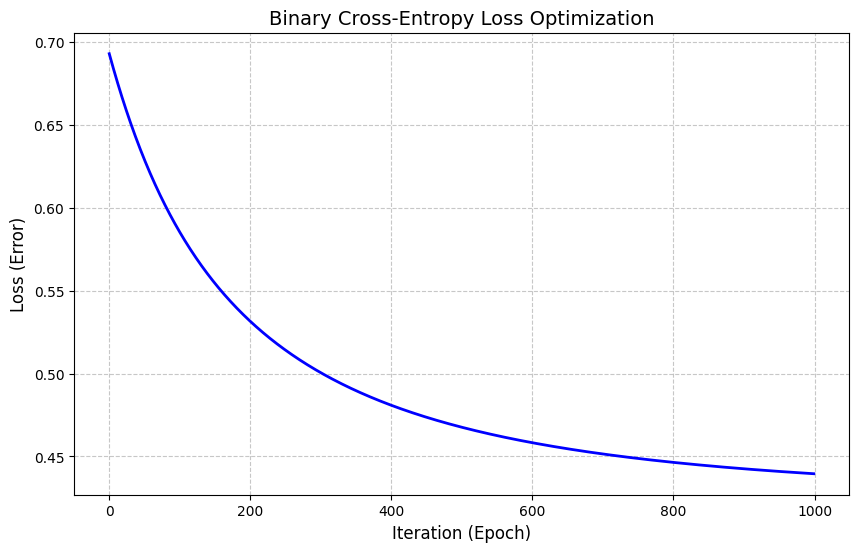

In [7]:
import matplotlib.pyplot as plt

def plot_loss_curve(loss_history):
    plt.figure(figsize=(10, 6))
    
    plt.plot(range(len(loss_history)), loss_history, color='blue', linewidth=2)
    
    plt.title("Binary Cross-Entropy Loss Optimization", fontsize=14)
    plt.xlabel("Iteration (Epoch)", fontsize=12)
    plt.ylabel("Loss (Error)", fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

plot_loss_curve(loss_history)

## 6. Evaluation

We classify a sample as positive ($\hat{y} = 1$) when $\sigma(z) \geq 0.5$,
which is equivalent to $z \geq 0$.

In [13]:
def predict(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    """Predict class labels (0 or 1)."""
    z = np.dot(X, w) + b
    #give me a chance that a person in titanic alive or dead
    chance = sigmoid(z)
    prediction = (chance > 0.5).astype(int)
    # print(prediction)
    return prediction

    


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute classification accuracy."""
    # we identify which one is indeed alive 
    correct_matches = (y_true == y_pred)
    # we calcualte what the percentage of our guess
    percentage = np.mean(correct_matches)
    return float(percentage)


# Evaluate on train and test sets
y_pred_train = predict(X_train_s, w, b)
y_pred_test = predict(X_test_s, w, b)

print(f"Our model — Train accuracy: {accuracy(y_train, y_pred_train):.4f}")
print(f"Our model — Test accuracy:  {accuracy(y_test, y_pred_test):.4f}")

-0.46585756425683833
-0.46585756425683833
Our model — Train accuracy: 0.6855
Our model — Test accuracy:  0.6742


## 7. Comparison with scikit-learn

We train the same model using scikit-learn's `LogisticRegression` (with the
same standardized data) to verify that our gradient descent implementation
arrives at comparable accuracy and weights.

In [12]:
# scikit-learn logistic regression (no regularization, to match our implementation)
sk_model = LogisticRegression(max_iter=200, random_state=42, C=np.inf)
sk_model.fit(X_train_s, y_train)

sk_accuracy = sk_model.score(X_test_s, y_test)
our_accuracy = accuracy(y_test, y_pred_test)

print(f"scikit-learn test accuracy: {sk_accuracy:.4f}")
print(f"Our GD test accuracy:      {our_accuracy:.4f}")
print(f"the difference: {sk_accuracy - our_accuracy:.4f}")
 
# Compare learned weights
print(f"{'Feature':>30s} | {'Ours':>8s} | {'sklearn':>8s}")
print("-" * 55)
for name, w_ours, w_sk in zip(FEATURES, w, sk_model.coef_[0]):
    print(f"{name:>30s} | {w_ours:+8.4f} | {w_sk:+8.4f}")
print(f"{'bias':>30s} | {b:+8.4f} | {sk_model.intercept_[0]:+8.4f}")

scikit-learn test accuracy: 0.7528
Our GD test accuracy:      0.6798
the difference: 0.0730
                       Feature |     Ours |  sklearn
-------------------------------------------------------
                           sex |  -1.0553 |  -2.9158
                           age |  -0.2637 |  -0.0375
                   family_size |  -0.2125 |  -0.3177
                          fare |  +0.2438 |  +0.0046
                     1st_class |  +0.3314 |  +1.6999
                     2nd_class |  +0.1116 |  +0.8495
                     3rd_class |  -0.3753 |  -0.4423
                          bias |  -0.4659 |  +2.1071


/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/u

## Summary

We implemented logistic regression from scratch using gradient descent and
verified it against scikit-learn. Key takeaways:

- The **sigmoid function** maps any real number to a probability in $(0, 1)$.
- The **binary cross-entropy loss** is convex, so gradient descent finds the
  global optimum.
- **Feature standardization** is critical for gradient descent to converge
  efficiently — without it, features on very different scales (e.g., Age vs.
  Fare) cause the loss surface to be poorly conditioned.
- Our hand-rolled implementation reaches the same accuracy and learns
  nearly identical weights as scikit-learn's optimized solver.